# Social Media Behaviour and Psychological Wellbeing

## Complete EDA → Research Question → Machine Learning

### Research question

> **Can digital behaviour predict wellbeing without using the psychological variables that define the wellbeing outcome?**

This notebook develops the analysis in a logical sequence:

1. Dataset overview
2. Missing-data treatment
3. Target variable
4. Univariate EDA
5. Correlation analysis
6. Target-focused bivariate EDA
7. Key findings and hypotheses
8. Research question and modelling strategy
9. Machine learning and evaluation

### Important methodological distinction

The psychological variables used to characterize wellbeing are **not used as ML predictors**:

- `anxiety_score_0to27`
- `low_mood_score_0to27`
- `life_satisfaction_1to10`
- `loneliness_1to10`
- `self_esteem_1to10`

This avoids circular prediction / target leakage.

For the strict interpretation of **digital behaviour alone**, we will distinguish a digital-only feature set from a broader set that also contains lifestyle and psychosocial variables.

In [38]:
# ============================================================
# 0. IMPORTS AND SETTINGS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TARGET = "wellbeing_band"
TARGET_ORDER = ["Good", "Moderate", "At-risk"]

# The notebook expects the CSV to be in the same directory as the notebook.
# If necessary, change this path manually.
DATA_PATH = Path("social_media_screentime_mental_health_2026.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\desena.fortuna\Desktop\socialmedia\social_media_screentime_mental_health_2026.csv


In [39]:
# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 7,000 rows × 25 columns


,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,minutes_to_first_check_after_waking,primary_purpose,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,25,Entertainment,8.7,17,0,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,26,Entertainment,7.3,18,2,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,12,Entertainment,7.0,12,6,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,21,News/information,7.0,13,0,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,19,Work/career,6.7,15,1,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


## 1. Dataset overview

The first step is to establish the structure and quality of the dataset before modelling.

We check:

- dimensions
- variable names
- data types
- unique participant IDs
- duplicate rows
- numerical vs categorical variables

In [40]:
# Dimensions
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Column names and data types
overview = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns],
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values
})

display(overview)

# Participant uniqueness
participant_col = "participant_id" if "participant_id" in df.columns else None

if participant_col:
    print("Unique participant IDs:", df[participant_col].nunique())
    print("Duplicate participant IDs:", df[participant_col].duplicated().sum())
else:
    print("No participant_id column was found.")

print("Duplicate complete rows:", df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("\nNumeric variables:", len(numeric_cols))
print("Categorical/object variables:", len(categorical_cols))

Rows: 7000
Columns: 25


,variable,dtype,unique_values,missing_count,missing_percent
0,participant_id,str,7000,0,0.0
1,age,int64,53,0,0.0
2,gender,str,4,70,1.0
3,occupation,str,6,0,0.0
4,region,str,6,0,0.0
5,most_used_platform,str,8,0,0.0
6,platforms_used_count,int64,8,0,0.0
7,daily_screen_hours,float64,116,0,0.0
8,daily_notifications,int64,291,0,0.0
9,night_time_use,str,4,0,0.0


Unique participant IDs: 7000
Duplicate participant IDs: 0
Duplicate complete rows: 0

Numeric variables: 14
Categorical/object variables: 11


### Variable groups

For interpretation, it is useful to separate variables conceptually.

**Digital behaviour variables** describe direct technology/social-media use.

**Psychological outcome variables** are excluded from prediction because they are closely tied to the wellbeing construct.

**Lifestyle/psychosocial variables** are kept separate because they are not purely digital behaviour.

In [41]:
digital_features = [
    "most_used_platform",
    "platforms_used_count",
    "daily_screen_hours",
    "daily_notifications",
    "night_time_use",
    "minutes_to_first_check_after_waking",
    "primary_purpose",
    "uses_screen_time_limits",
    "attempted_digital_detox"
]

psychological_outcome_variables = [
    "anxiety_score_0to27",
    "low_mood_score_0to27",
    "life_satisfaction_1to10",
    "loneliness_1to10",
    "self_esteem_1to10"
]

lifestyle_psychosocial = [
    "avg_sleep_hours",
    "fomo_1to10",
    "social_comparison_1to10",
    "physical_activity_days_per_week",
    "seeks_mental_health_support"
]

demographic_variables = [
    "age",
    "gender",
    "occupation",
    "region",
    "age_group"
]

# Keep only variables that are actually present.
digital_features = [c for c in digital_features if c in df.columns]
psychological_outcome_variables = [c for c in psychological_outcome_variables if c in df.columns]
lifestyle_psychosocial = [c for c in lifestyle_psychosocial if c in df.columns]
demographic_variables = [c for c in demographic_variables if c in df.columns]

print("Digital features:", digital_features)
print("Psychological outcome variables:", psychological_outcome_variables)
print("Lifestyle/psychosocial variables:", lifestyle_psychosocial)
print("Demographic variables:", demographic_variables)

Digital features: ['most_used_platform', 'platforms_used_count', 'daily_screen_hours', 'daily_notifications', 'night_time_use', 'minutes_to_first_check_after_waking', 'primary_purpose', 'uses_screen_time_limits', 'attempted_digital_detox']
Psychological outcome variables: ['anxiety_score_0to27', 'low_mood_score_0to27', 'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10']
Lifestyle/psychosocial variables: ['avg_sleep_hours', 'fomo_1to10', 'social_comparison_1to10', 'physical_activity_days_per_week', 'seeks_mental_health_support']
Demographic variables: ['age', 'gender', 'occupation', 'region']


# 2. Missing-data treatment

Missing values should be investigated **before** deciding whether to delete or impute observations.

For the uploaded cleaned CSV, we expect the missing-value table to show zero missing values. If the original raw dataset is available, its missingness analysis should be reported separately rather than silently mixing the raw and cleaned versions.

In [42]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_table)

if missing_table["missing_count"].sum() == 0:
    print("Conclusion: the uploaded CSV contains no missing values.")
    print("No imputation or further deletion is required for this file.")
else:
    display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_percent
avg_sleep_hours,105,1.5
gender,70,1.0
participant_id,0,0.0
occupation,0,0.0
age,0,0.0
most_used_platform,0,0.0
platforms_used_count,0,0.0
daily_screen_hours,0,0.0
region,0,0.0
daily_notifications,0,0.0


,missing_count,missing_percent
avg_sleep_hours,105,1.5
gender,70,1.0


### Missing-data decision

If a raw dataset contains a small amount of missingness, complete-case deletion can be reasonable when:

- the proportion removed is small,
- the missingness does not appear systematically related to important observed variables,
- and the analysis is not sensitive to the lost observations.

However, the strongest approach is to investigate the missingness mechanism and compare important distributions before and after cleaning.

**Important:** no missingness mechanism should be claimed from the cleaned file alone.

In [43]:
# Optional comparison helper if a raw dataframe is available later.
# Example:
#
# raw_df = pd.read_csv("original_raw_dataset.csv")
# clean_df = df.copy()
#
# Compare:
# raw_df.shape, clean_df.shape
# raw_df.describe(include="all"), clean_df.describe(include="all")
#
# This section is intentionally not executed because the uploaded CSV is already cleaned.

# 3. Target variable

The target is `wellbeing_band`, with three classes:

- **Good**
- **Moderate**
- **At-risk**

The class distribution must be understood before ML because imbalanced classes can make ordinary accuracy misleading.

In [44]:
target_counts = df[TARGET].value_counts().reindex(TARGET_ORDER)
target_percent = (target_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

display(target_summary)

print(f"Minority class proportion: {target_percent['At-risk']:.2f}%")
print(f"Majority class proportion: {target_percent['Moderate']:.2f}%")

,count,percentage
wellbeing_band,,
Good,2260,32.29
Moderate,3766,53.80
At-risk,974,13.91


Minority class proportion: 13.91%
Majority class proportion: 53.80%


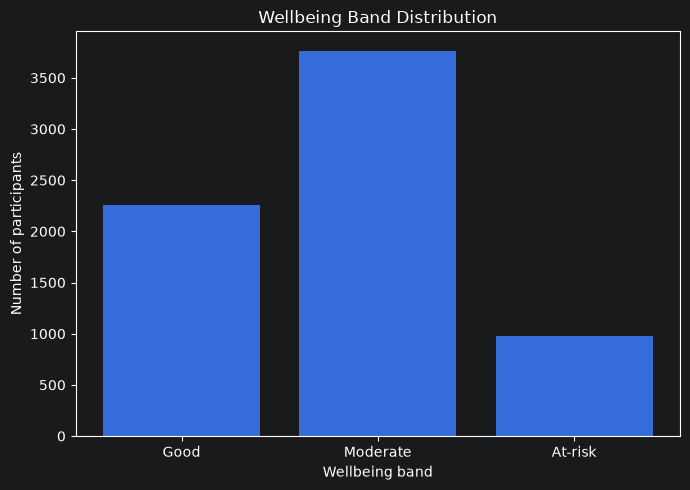

In [45]:
# Target distribution visualization
plt.figure(figsize=(7, 5))
plt.bar(TARGET_ORDER, target_counts.values)
plt.title("Wellbeing Band Distribution")
plt.xlabel("Wellbeing band")
plt.ylabel("Number of participants")
plt.tight_layout()
plt.show()

### Interpretation

The target is meaningfully imbalanced:

- Moderate is the majority class.
- At-risk is the minority class.

Therefore, ML evaluation should report:

- accuracy
- balanced accuracy
- macro-F1
- per-class precision
- per-class recall
- per-class F1
- confusion matrix

Class weighting can also be used during training.

# 4. Univariate EDA

Univariate analysis describes each variable individually.

The goal is not to produce as many plots as possible, but to understand:

- typical values
- spread
- skewness
- possible outliers
- categorical frequencies
- variables that deserve target-focused analysis

In [46]:
# Numerical descriptive statistics
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,7000.0,29.246571,9.569132,13.0,22.0,29.0,36.0,71.0
platforms_used_count,7000.0,3.494571,1.763637,1.0,2.0,3.0,5.0,8.0
daily_screen_hours,7000.0,3.304971,1.881350,0.2,1.9,3.0,4.3,14.0
daily_notifications,7000.0,61.528286,54.879070,5.0,24.0,45.5,83.0,400.0
minutes_to_first_check_after_waking,7000.0,20.008286,13.976229,0.0,10.0,17.0,27.0,111.0
avg_sleep_hours,6895.0,6.964989,0.870575,3.8,6.4,7.0,7.6,10.0
anxiety_score_0to27,7000.0,11.378000,4.777726,0.0,8.0,11.0,14.0,27.0
low_mood_score_0to27,7000.0,3.845714,3.534197,0.0,0.0,3.0,6.0,19.0
life_satisfaction_1to10,7000.0,6.955857,1.614486,1.0,6.0,7.0,8.0,10.0
loneliness_1to10,7000.0,4.679286,2.094803,1.0,3.0,5.0,6.0,10.0


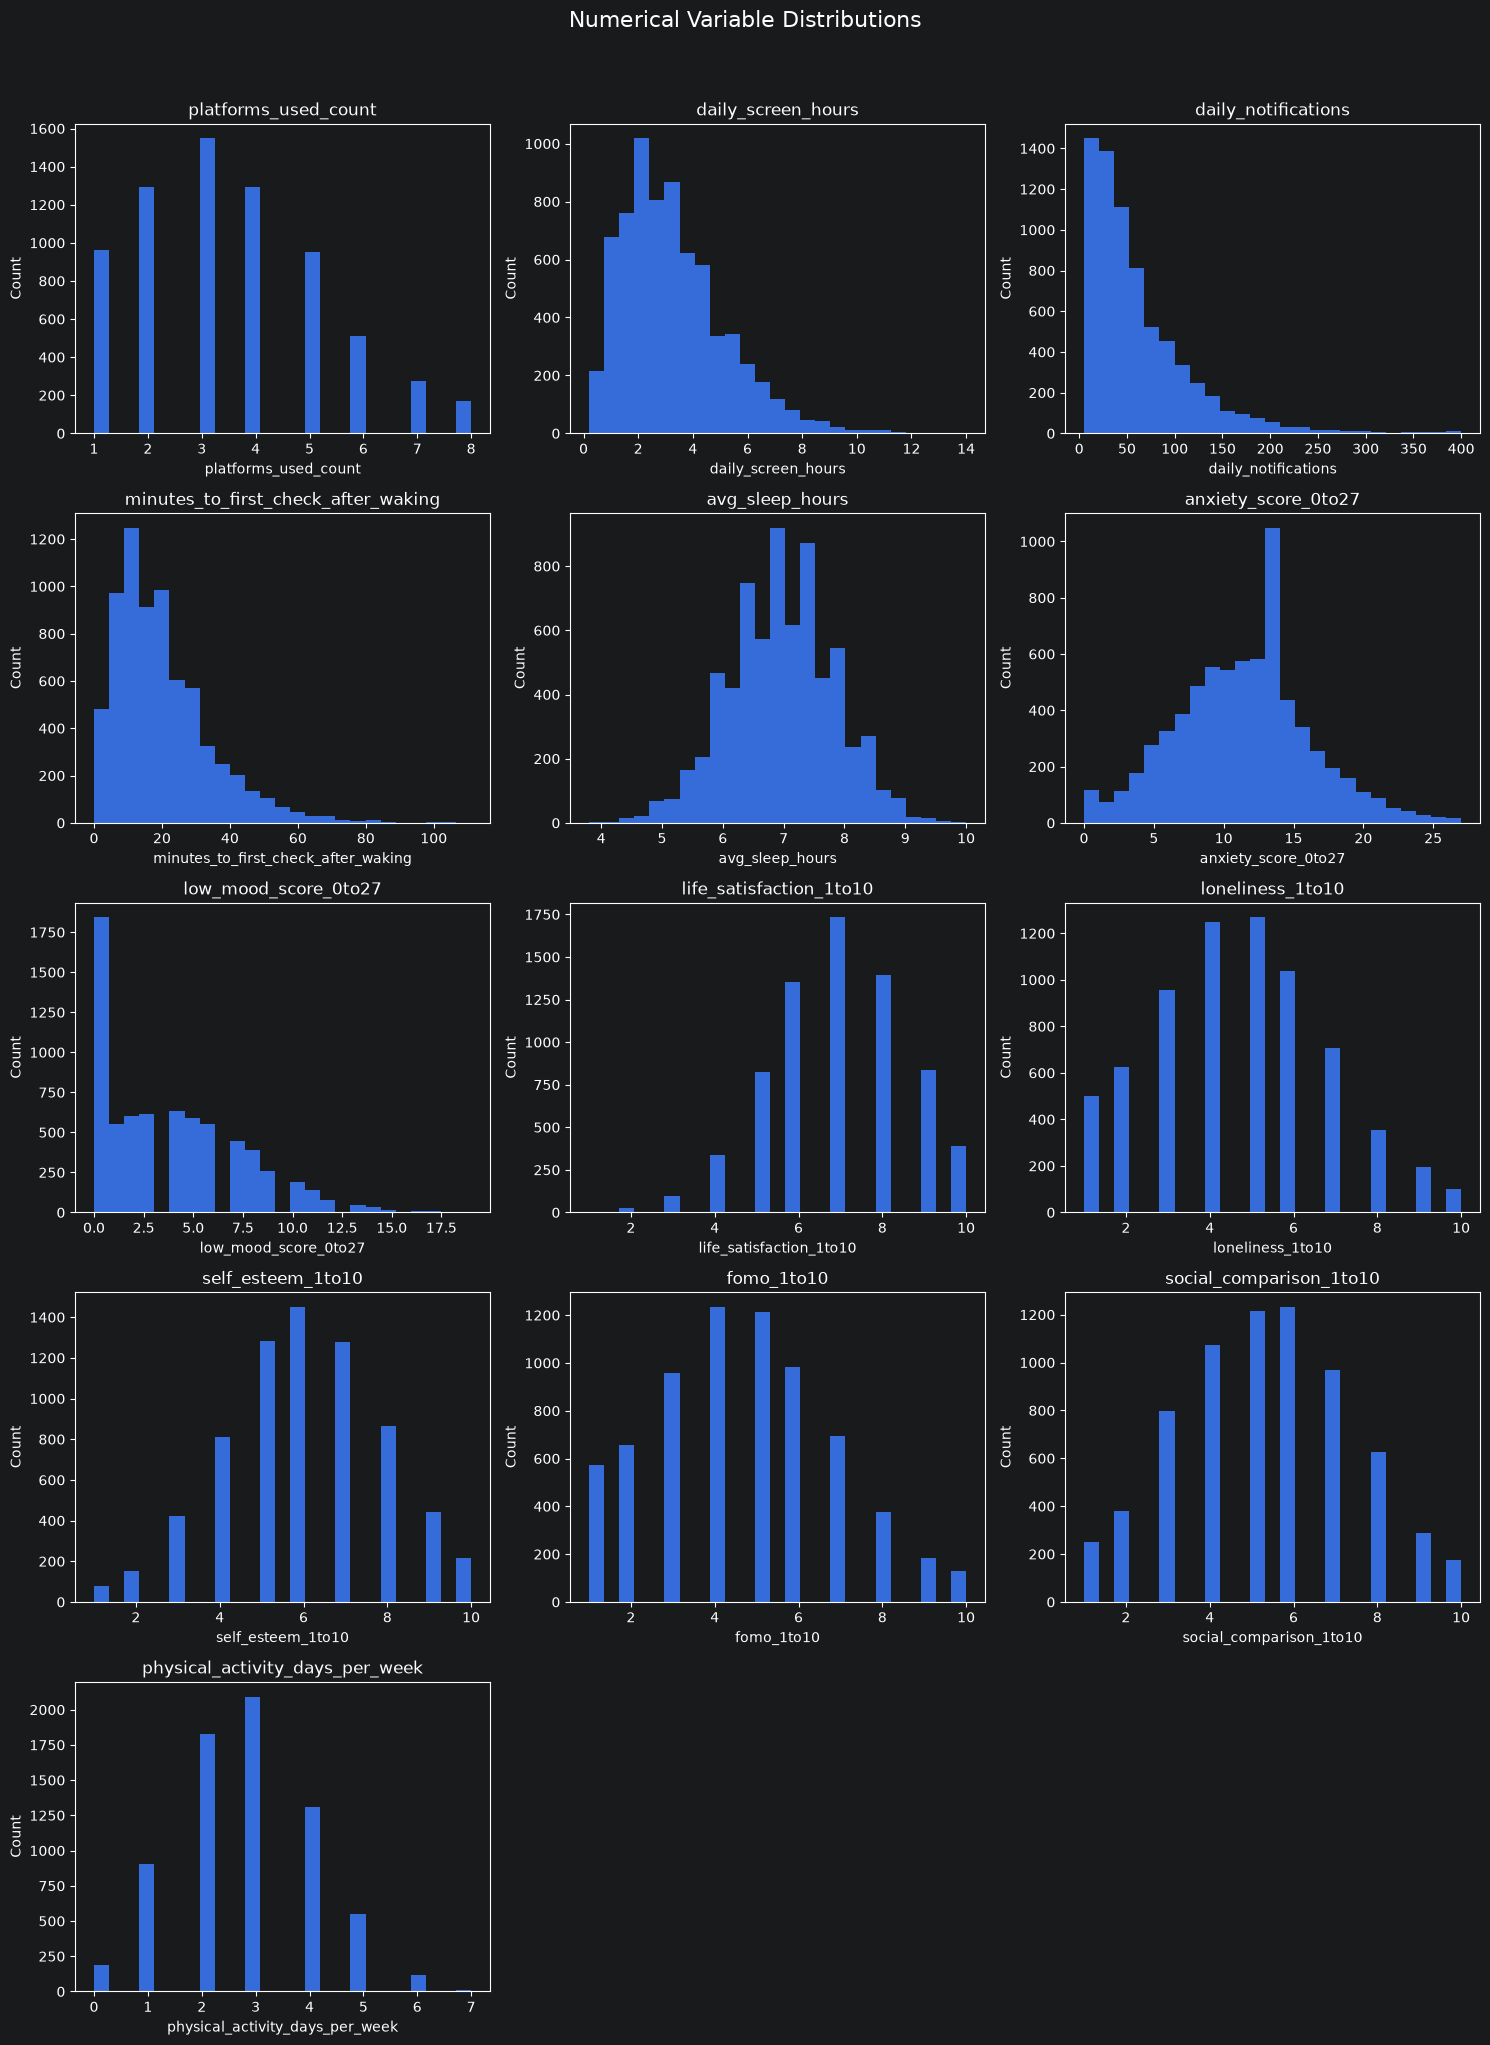

In [47]:
# Numerical distributions
numeric_for_plot = [c for c in numeric_cols if c != "age"]

n = len(numeric_for_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_for_plot):
    ax.hist(df[col].dropna(), bins=25)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(numeric_for_plot):]:
    ax.axis("off")

plt.suptitle("Numerical Variable Distributions", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

TypeError: 'value' must be an instance of str or bytes, not a float

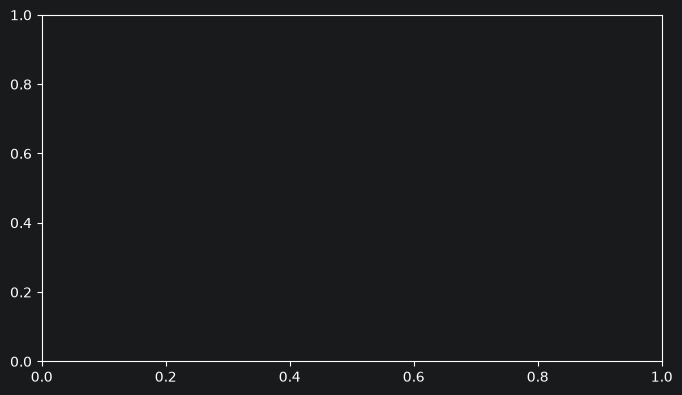

In [48]:
# Categorical distributions
categorical_for_plot = [
    c for c in categorical_cols
    if c not in ["participant_id", TARGET]
]

for col in categorical_for_plot:
    counts = df[col].value_counts(dropna=False)

    plt.figure(figsize=(8, 4.5))
    plt.bar(counts.index.astype(str),
            counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

### Univariate interpretation

The most important variables to carry forward are those that are both substantively relevant and show meaningful variation.

In this dataset, daily screen time and notifications have substantial spread and high-use observations. Sleep, FOMO, and social comparison are bounded scales and are particularly useful for comparing wellbeing groups.

Univariate analysis alone does **not** establish that any variable predicts wellbeing. That question is addressed next through correlations and target-focused comparisons.

# 5. Correlation analysis

Pearson correlation measures the strength and direction of a **linear association** between two numerical variables.

It does not establish causality.

A positive correlation means that higher values of one variable tend to occur with higher values of another. A negative correlation means that higher values of one tend to occur with lower values of another.

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Pearson correlation (r)")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90, fontsize=8)
plt.yticks(range(len(numeric_cols)), numeric_cols, fontsize=8)
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
# Extract strongest unique correlations
pairs = []

for i, col_a in enumerate(numeric_cols):
    for col_b in numeric_cols[i + 1:]:
        r = corr.loc[col_a, col_b]
        if pd.notna(r):
            pairs.append((col_a, col_b, r, abs(r)))

strongest_correlations = (
    pd.DataFrame(pairs, columns=["variable_1", "variable_2", "r", "abs_r"])
    .sort_values("abs_r", ascending=False)
)

display(strongest_correlations.head(15))

### Important correlations in this dataset

The strongest relationship is between:

**daily screen hours ↔ daily notifications**

This indicates that heavier screen use tends to occur with more notifications.

Daily screen time is also positively associated with anxiety and FOMO, and negatively associated with sleep and life satisfaction.

These relationships are **associations, not causal conclusions**. For example, higher screen time may be associated with poorer wellbeing, but this analysis cannot determine whether screen use causes poorer wellbeing, poorer wellbeing causes greater screen use, or both are influenced by other variables.

# 6. Target-focused bivariate EDA

This is the most important EDA section for the research question.

Instead of asking only:

> How are two predictors related?

we ask:

> **How does each candidate predictor differ across wellbeing groups?**

This creates the bridge from exploratory analysis to supervised ML.

In [ ]:
# Mean values by wellbeing group
mean_by_target = df.groupby(TARGET)[numeric_cols].mean().reindex(TARGET_ORDER)
display(mean_by_target.T.round(2))

In [ ]:
# Boxplots for the most relevant numeric candidate predictors
target_numeric_candidates = [
    "daily_screen_hours",
    "daily_notifications",
    "avg_sleep_hours",
    "minutes_to_first_check_after_waking",
    "platforms_used_count",
    "fomo_1to10",
    "social_comparison_1to10",
    "physical_activity_days_per_week"
]

target_numeric_candidates = [
    c for c in target_numeric_candidates if c in df.columns
]

for col in target_numeric_candidates:
    data = [
        df.loc[df[TARGET] == group, col].dropna()
        for group in TARGET_ORDER
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(data, tick_labels=TARGET_ORDER, showfliers=False)
    plt.title(f"{col} by Wellbeing Band")
    plt.xlabel("Wellbeing band")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Statistical tests for numeric variables

Because several variables are bounded, skewed, or ordinal-like, the **Kruskal–Wallis test** is used as a robust non-parametric test for whether the distributions differ across the three wellbeing groups.

A statistically significant result tells us that at least one group differs. It does not by itself tell us which groups differ or establish causality.

In [ ]:
kw_results = []

for col in target_numeric_candidates:
    groups = [
        df.loc[df[TARGET] == group, col].dropna()
        for group in TARGET_ORDER
    ]

    statistic, p_value = kruskal(*groups)
    kw_results.append([col, statistic, p_value])

kw_results = pd.DataFrame(
    kw_results,
    columns=["variable", "Kruskal_Wallis_H", "p_value"]
).sort_values("p_value")

display(kw_results)

### Categorical variables versus wellbeing

For categorical variables, we use a contingency table and Cramer's V.

Cramer's V measures the strength of association between two categorical variables:

- values near 0 indicate very weak association,
- larger values indicate stronger association.

With a large sample, a tiny effect can be statistically significant, so **effect size matters as well as p-value**.

In [ ]:
def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape

    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    v = np.sqrt(phi2_corr / max(1e-12, min(k_corr - 1, r_corr - 1)))
    return v, p

categorical_target_candidates = [
    "gender",
    "occupation",
    "region",
    "most_used_platform",
    "night_time_use",
    "primary_purpose",
    "uses_screen_time_limits",
    "attempted_digital_detox",
    "seeks_mental_health_support",
    "age_group"
]

categorical_target_candidates = [
    c for c in categorical_target_candidates if c in df.columns
]

cat_results = []

for col in categorical_target_candidates:
    table = pd.crosstab(df[col], df[TARGET])
    v, p = cramers_v(table)
    cat_results.append([col, v, p])

cat_results = pd.DataFrame(
    cat_results,
    columns=["variable", "cramers_v", "p_value"]
).sort_values("cramers_v", ascending=False)

display(cat_results)

In [ ]:
# Wellbeing percentages within each category for selected categorical variables
selected_categorical = [
    "most_used_platform",
    "night_time_use",
    "primary_purpose",
    "uses_screen_time_limits",
    "attempted_digital_detox"
]

for col in selected_categorical:
    if col in df.columns:
        percentage_table = (
            pd.crosstab(df[col], df[TARGET], normalize="index")
            .reindex(columns=TARGET_ORDER)
            .mul(100)
            .round(1)
        )

        print(f"\n{col} — wellbeing percentage within category")
        display(percentage_table)

### Target-focused interpretation

The clearest numerical separation is observed for:

- daily screen time
- daily notifications
- average sleep
- FOMO
- social comparison

The number of platforms used and physical-activity frequency show little meaningful separation between the wellbeing groups.

Night-time use has a statistically detectable association, but its effect size is small.

This distinction is important: **statistical significance does not automatically mean practical importance.**

# 7. Key findings and hypotheses

The EDA supports the following hypotheses to carry into machine learning:

### H1 — Screen time
Higher daily screen time is associated with poorer wellbeing.

### H2 — Notifications
Higher daily notification frequency is associated with poorer wellbeing.

### H3 — Night-time use
Night-time social-media use is associated with wellbeing, although the observed categorical effect is small.

### H4 — Sleep
Lower average sleep is associated with poorer wellbeing.

### H5 — FOMO
Higher FOMO is associated with poorer wellbeing.

### H6 — Social comparison
Higher social comparison is associated with poorer wellbeing.

### H7 — Platform count
The number of platforms used is not strongly associated with wellbeing in this sample.

### H8 — Prediction
Digital behaviour contains enough information to provide predictive signal about wellbeing even when the psychological outcome-definition variables are excluded.

These are **hypotheses/associations**, not causal claims.

# 8. Research question and modelling strategy

## Primary research question

> **Can digital behaviour predict wellbeing without using the psychological variables that define the wellbeing outcome?**

### Strict digital-only model

The first model uses only direct digital-use variables:

- platform
- number of platforms
- screen time
- notifications
- night-time use
- first phone check
- primary purpose
- screen-time limits
- digital detox

### Broader comparison model

A second model adds demographics plus lifestyle/psychosocial variables:

- age and demographics
- sleep
- FOMO
- social comparison
- physical activity
- mental-health support

This comparison is important because **sleep, physical activity, FOMO, and social comparison are not purely digital behaviours**.

The psychological variables that characterize wellbeing remain excluded from both models.

In [ ]:
# ============================================================
# 9. MACHINE LEARNING
# ============================================================

# Strict digital-only predictors
X_digital = df[digital_features].copy()

# Broader predictors: digital + demographics + lifestyle/psychosocial
broader_features = (
    digital_features
    + demographic_variables
    + lifestyle_psychosocial
)

# Remove any accidental duplicates while preserving order
broader_features = list(dict.fromkeys(broader_features))
X_broader = df[broader_features].copy()

y = df[TARGET].copy()

print("Digital-only features:")
print(digital_features)

print("\nBroader model features:")
print(broader_features)

print("\nExcluded psychological variables:")
print(psychological_outcome_variables)

In [ ]:
# Stratified split: preserves the target proportions in train and test data
X_d_train, X_d_test, y_train, y_test = train_test_split(
    X_digital,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_b_train, X_b_test, _, _ = train_test_split(
    X_broader,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training observations:", len(X_d_train))
print("Test observations:", len(X_d_test))

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).reindex(TARGET_ORDER).mul(100).round(2))

print("Test target distribution:")
display(y_test.value_counts(normalize=True).reindex(TARGET_ORDER).mul(100).round(2))

In [ ]:
def make_preprocessor(X):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = X.select_dtypes(include=["object", "category"]).columns.tolist()

    return ColumnTransformer([
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        )
    ])

models = {
    "Digital + Logistic Regression": (
        X_d_train, X_d_test,
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    ),
    "Digital + Random Forest": (
        X_d_train, X_d_test,
        RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    "Broader + Logistic Regression": (
        X_b_train, X_b_test,
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    ),
    "Broader + Random Forest": (
        X_b_train, X_b_test,
        RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
}

fitted_models = {}
model_results = []

for name, (X_train_model, X_test_model, model) in models.items():
    pipe = Pipeline([
        ("preprocessor", make_preprocessor(X_train_model)),
        ("model", model)
    ])

    pipe.fit(X_train_model, y_train)
    pred = pipe.predict(X_test_model)

    fitted_models[name] = (pipe, pred)

    model_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro")
    })

model_results = (
    pd.DataFrame(model_results)
    .sort_values("balanced_accuracy", ascending=False)
)

display(model_results.round(3))

### Why balanced accuracy and macro-F1?

The target is imbalanced. A model can achieve reasonable overall accuracy while performing poorly on the minority At-risk class.

**Balanced accuracy** gives equal importance to recall for each class.

**Macro-F1** calculates F1 for each class and then gives each class equal weight.

For this project, these metrics are more informative than accuracy alone.

In [ ]:
# Detailed report for the best model by balanced accuracy
best_model_name = model_results.iloc[0]["model"]
best_pipe, best_pred = fitted_models[best_model_name]

print("Best model:", best_model_name)
print()
print(classification_report(
    y_test,
    best_pred,
    labels=TARGET_ORDER,
    target_names=TARGET_ORDER,
    digits=3
))

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred, labels=TARGET_ORDER)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=TARGET_ORDER
)
disp.plot(ax=ax, values_format="d", colorbar=True)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

### Interpreting the confusion matrix

Rows represent the **actual** wellbeing class.

Columns represent the **predicted** class.

The diagonal contains correct classifications. Off-diagonal cells show where the model confuses one wellbeing group with another.

For a practical risk-detection task, particular attention should be paid to **At-risk recall**: how many genuinely At-risk participants the model successfully identifies.

## Cross-validation

A single train/test split provides one estimate of performance. To make the result more robust, we also use stratified cross-validation.

Cross-validation repeatedly trains and evaluates the model on different partitions while preserving the class proportions.

In [ ]:
# Compare the two most relevant models using 5-fold stratified CV.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_models = {
    "Digital + Logistic Regression": (
        X_digital,
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    ),
    "Digital + Random Forest": (
        X_digital,
        RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    "Broader + Logistic Regression": (
        X_broader,
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    ),
    "Broader + Random Forest": (
        X_broader,
        RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
}

cv_rows = []

for name, (X_model, model) in cv_models.items():
    pipe = Pipeline([
        ("preprocessor", make_preprocessor(X_model)),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_model,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "macro_f1": "f1_macro"
        },
        n_jobs=-1
    )

    cv_rows.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_sd": scores["test_accuracy"].std(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_balanced_accuracy_sd": scores["test_balanced_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_sd": scores["test_macro_f1"].std()
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("cv_balanced_accuracy_mean", ascending=False)
)

display(cv_results.round(3))

# Feature importance

Random Forest impurity importance can identify variables that contribute strongly to tree splits.

However, impurity-based importance can be biased when variables have many possible split points or categories.

Therefore, treat this as a first interpretation and, where possible, confirm the findings with **permutation importance**.

In [ ]:
# Fit the digital-only Random Forest again so that we can inspect its feature names.
digital_rf = Pipeline([
    ("preprocessor", make_preprocessor(X_digital)),
    ("model", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

digital_rf.fit(X_d_train, y_train)

preprocessor = digital_rf.named_steps["preprocessor"]
rf = digital_rf.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_importances = importances.head(15).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_importances.index, top_importances.values)
plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Top Predictive Features — Digital-only Random Forest")
plt.tight_layout()
plt.show()

display(importances.head(15).to_frame("importance"))

## Practical interpretation of the ML stage

The initial analysis shows that digital behaviour contains predictive information, but the three wellbeing classes overlap considerably.

A useful result is therefore **not** necessarily a very high accuracy. The more meaningful conclusion is whether digital variables consistently perform better than a naive baseline and whether they can identify the minority At-risk group.

The strict digital-only model is the key model for answering the research question. The broader model is a useful comparison showing what happens when lifestyle and psychosocial variables are added.

In [ ]:
# Naive majority-class baseline
majority_class = y_train.value_counts().idxmax()
baseline_pred = np.repeat(majority_class, len(y_test))

print("Naive majority class:", majority_class)
print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 3))
print(
    "Baseline balanced accuracy:",
    round(balanced_accuracy_score(y_test, baseline_pred), 3)
)

print("\nCompare this baseline with the model table above.")

# Final conclusions

## What the EDA shows

1. The target is imbalanced, with Moderate as the largest class and At-risk as the smallest.
2. Daily screen time has the clearest digital-behaviour separation across wellbeing groups.
3. Daily notifications show a similarly strong gradient.
4. Lower sleep and higher FOMO/social comparison are associated with poorer wellbeing.
5. Number of platforms and physical activity show little target separation.
6. Several digital-use variables are correlated with each other, so multivariable modelling is necessary.

## What the ML should test

The ML stage tests whether these associations translate into **individual-level prediction**.

The key conclusion should be phrased as:

> **Digital behaviour contains predictive information about wellbeing, but it does not perfectly determine wellbeing category.**

This is a predictive conclusion, **not a causal conclusion**.

## Methodological limitation

The strict research question concerns digital behaviour alone. Therefore, sleep, physical activity, FOMO, and social comparison should not be described as digital variables. The comparison between the digital-only and broader models makes this distinction explicit.

## Recommended next analyses

- permutation importance
- binary **At-risk vs non-At-risk** classification
- ROC-AUC / PR-AUC where appropriate
- calibration analysis
- error analysis of misclassified participants
- subgroup performance by age/gender/occupation
- sensitivity analysis with different feature sets